Esta notebook contiene bloques de código útiles para realizar Q-learning en el entorno "Continuous Mountain Car"

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random 

In [2]:
# Cambiar render_mode a rgb_array para entrenar/testear
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='rgb_array')

Observation Space

In [3]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [4]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [5]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [6]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [7]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [8]:
actions = list(np.linspace(-1, 1, 15))
actions

[np.float64(-1.0),
 np.float64(-0.8571428571428572),
 np.float64(-0.7142857142857143),
 np.float64(-0.5714285714285714),
 np.float64(-0.4285714285714286),
 np.float64(-0.2857142857142858),
 np.float64(-0.1428571428571429),
 np.float64(0.0),
 np.float64(0.1428571428571428),
 np.float64(0.2857142857142856),
 np.float64(0.4285714285714284),
 np.float64(0.5714285714285714),
 np.float64(0.7142857142857142),
 np.float64(0.857142857142857),
 np.float64(1.0)]

In [9]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [10]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [11]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [12]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

Ejemplo de episodio 

In [16]:
obs,_ = env.reset()
print(obs)
done = False
total_reward = 0
state = get_state(obs)
steps = 0
while not done:
    steps += 1
    # Acción del modelo
    action = epsilon_greedy_policy(state, Q, 0.5)
    
    # Indice de la accion en Q
    action_idx = actions.index(action)
    
    # Acción del ambiente
    real_action = np.array([action])
     
    obs, reward, done, _, _ = env.step(real_action)
    next_state = get_state(obs)
    next_action = epsilon_greedy_policy(next_state, Q, 0.5)

    alpha = 0.1
    gamma = 0.99
   # Usar action_idx para actualizar Q
    Q[state][action_idx] = Q[state][action_idx] + alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action_idx])
   # Actualizar estado
    state = next_state
   
    total_reward += reward

    env.render()

env.close()    
print('total_reward', total_reward)
print('steps', steps)

[-0.4757504  0.       ]


KeyboardInterrupt: 

In [13]:
from q_learning_agent import QLearningAgent

In [14]:
all_rewards = []

for i in range(10):
    print(f"--- Iniciando entrenamiento del Agente {i+1} ---")
    agent = QLearningAgent()
    rewards = agent.train_agent(env)
    all_rewards.append(rewards)


--- Iniciando entrenamiento del Agente 1 ---
89.13474063311381
--- Iniciando entrenamiento del Agente 2 ---
89.14071771330013
--- Iniciando entrenamiento del Agente 3 ---
88.69154069091256
--- Iniciando entrenamiento del Agente 4 ---
89.50243324881839
--- Iniciando entrenamiento del Agente 5 ---
89.50577795574046
--- Iniciando entrenamiento del Agente 6 ---
88.31342337912714
--- Iniciando entrenamiento del Agente 7 ---
87.89353187410241
--- Iniciando entrenamiento del Agente 8 ---
89.72969666431455
--- Iniciando entrenamiento del Agente 9 ---
87.64177247894759
--- Iniciando entrenamiento del Agente 10 ---
83.25795468159532


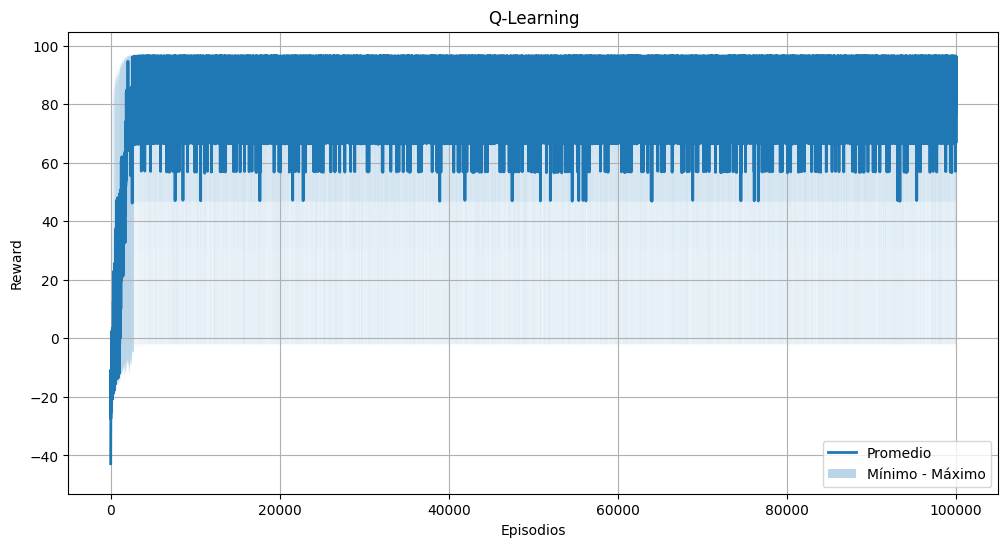

In [15]:
all_rewards = np.array(all_rewards)

mean_reward = np.mean(all_rewards, axis=0)
min_reward = np.min(all_rewards, axis=0)
max_reward = np.max(all_rewards, axis=0)

episodes = np.arange(len(mean_reward))

plt.figure(figsize=(12,6))

plt.plot(
    episodes,
    mean_reward,
    linewidth=2,
    label="Promedio"
)

plt.fill_between(
    episodes,
    min_reward,
    max_reward,
    alpha=0.3,
    label="Mínimo - Máximo"
)

plt.xlabel("Episodios")
plt.ylabel("Reward")
plt.title("Q-Learning")
plt.grid(True)
plt.legend()

plt.show()

In [6]:
import pickle

with open("exp_1.pkl", "wb") as f:
    pickle.dump(agent.Q, f)

In [7]:
with open("exp_1.pkl", "rb") as f:
    objeto_cargado = pickle.load(f)

print(objeto_cargado)

[[[0.02440852 0.63157608 0.42449346 ... 0.12992296 0.47138357 0.26322095]
  [0.58271069 0.02828399 0.79337674 ... 0.50721617 0.2584267  0.32908654]
  [0.8272611  0.78906028 0.43084043 ... 0.00964508 0.70407734 0.74166733]
  ...
  [0.0718575  0.74953406 0.70146064 ... 0.36273766 0.92893075 0.39125778]
  [0.56478916 0.21195226 0.51466175 ... 0.61834555 0.34301731 0.42187383]
  [0.81723309 0.74358275 0.2409133  ... 0.46303686 0.82714453 0.62967135]]

 [[0.87350742 0.3708029  0.98921898 ... 0.89863331 0.43551419 0.09419053]
  [0.72500046 0.86988497 0.5012999  ... 0.12422348 0.11726944 0.39121706]
  [0.8062173  0.83575059 0.89790595 ... 0.25918617 0.18533562 0.63399655]
  ...
  [0.96628636 0.49286032 0.3936813  ... 0.79740977 0.28979416 0.42457147]
  [0.04377882 0.23357277 0.90547247 ... 0.21582157 0.33825844 0.29430899]
  [0.36050402 0.26319156 0.12795063 ... 0.56574973 0.69588734 0.4241254 ]]

 [[0.13801158 0.52807993 0.76516318 ... 0.16237182 0.47191545 0.10333084]
  [0.19518152 0.978819